In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from transformers import AudioFilterResampler, MelSpectrogramTransformer, SpectrogramPadder, FlattenTransformer, FeatureExtractor

from config import TEST_SIZE, SEED

# Conformación del Dataset Final

In [ ]:
df = pd.read_csv('./icbhi/ICBHI_ciclos/ICBHI_ciclos_metadata.csv')

In [3]:
df['label'] = np.where((df['crackles'] == 0) & (df['wheezes'] == 0), 0, 1)
df.head()

,patient,recording_index,location,mode,instrument,cycle_number,start_sec,end_sec,duration_sec,crackles,wheezes,cycle_wav_file,wav_base_file,age,sex,adult_bmi,child_weight,child_height,diagnosis,label
0,101,1b1,Al,sc,Meditron,1,0.036,0.579,0.543,0,0,101_1b1_Al_sc_Meditron_cycle1.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0
1,101,1b1,Al,sc,Meditron,2,0.579,2.450,1.871,0,0,101_1b1_Al_sc_Meditron_cycle2.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0
2,101,1b1,Al,sc,Meditron,3,2.450,3.893,1.443,0,0,101_1b1_Al_sc_Meditron_cycle3.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0
3,101,1b1,Al,sc,Meditron,4,3.893,5.793,1.900,0,0,101_1b1_Al_sc_Meditron_cycle4.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0
4,101,1b1,Al,sc,Meditron,5,5.793,7.521,1.728,0,0,101_1b1_Al_sc_Meditron_cycle5.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0


## Duración de los ciclos respiratorios
La aplicación debería contar con un instructivo mostrando el ritmo de respiración esperado. De esta manera los ciclos detectados por el "segmentador" tendrán mas o menos la misma duración. 

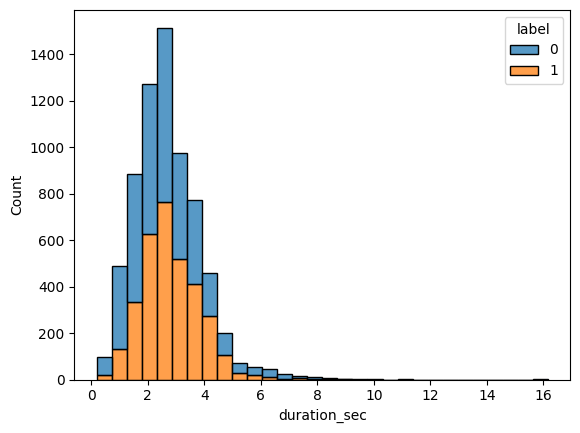

In [4]:
sns.histplot(data=df, x='duration_sec', bins=30, hue='label', multiple='stack');

Las duracion sugerida por el instructivo debería estar en el bulk de la distribución observada.  

¿ Qué hacemos con los ciclos que son demasiado cortos? La segmentación no tolera ciclos demasiado cortos.  

Tampoco debería tolerar los demasiado largos, pero esos son pocos y eliminarlos no es tan costoso.

In [5]:
ciclos_cortos = df[df['duration_sec'] < 2]
ciclos_cortos.head()

,patient,recording_index,location,mode,instrument,cycle_number,start_sec,end_sec,duration_sec,crackles,wheezes,cycle_wav_file,wav_base_file,age,sex,adult_bmi,child_weight,child_height,diagnosis,label
0,101,1b1,Al,sc,Meditron,1,0.036,0.579,0.543,0,0,101_1b1_Al_sc_Meditron_cycle1.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0
1,101,1b1,Al,sc,Meditron,2,0.579,2.450,1.871,0,0,101_1b1_Al_sc_Meditron_cycle2.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0
2,101,1b1,Al,sc,Meditron,3,2.450,3.893,1.443,0,0,101_1b1_Al_sc_Meditron_cycle3.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0
3,101,1b1,Al,sc,Meditron,4,3.893,5.793,1.900,0,0,101_1b1_Al_sc_Meditron_cycle4.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0
4,101,1b1,Al,sc,Meditron,5,5.793,7.521,1.728,0,0,101_1b1_Al_sc_Meditron_cycle5.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0


## Versiones del dataset final
Se plantean dos versiones del dataset final:
1. Versión completa: contiene todos los ciclos respiratorios de la ICBHI RSDB.
    + Ventajas:
        + Mayor cantidad de datos
        + Capa MixStyles en CNN puede usar información adicional (?)
        + En caso de extenderse el uso del modelo a estetoscopios digitales no habría que hacer cambios.
    + Desventajas:
        + Dificultad de adaptar al dominio de smartphones
        + Costo computacional alto (mi máquina no puede correr CV se SK-Learn)
2. Versión filtrada: sólo los audios grabados con el micrófono AKGC417L o desde la tráquea.
    + Ventajas:
        + Menor costo computacional
        + Menor dificultad en adaptar al dominio
        + Más representativo de los audios esperados en producción
    + Desventajas:
        + Pérdida de datos
        + Más específico al caso (puede ser una ventaja también, no aprendería cosas innecesarias)

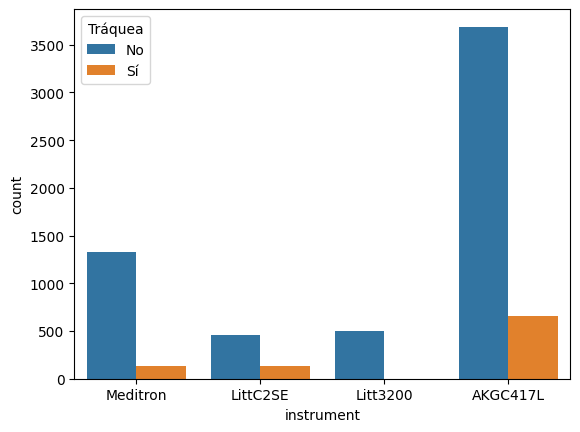

In [39]:
sns.countplot(data=df, x='instrument', hue=df['location'] == 'Tc')
plt.legend(title='Tráquea', labels=['No', 'Sí']);

In [41]:
dataset_completo = df.copy()

dataset_filtrado = df[(df['instrument'] == 'AKGC417L') | (df['location'] == 'Tc')].copy()

## Balancear

Primero miramos la etiqueta objetivo del futuro modelo

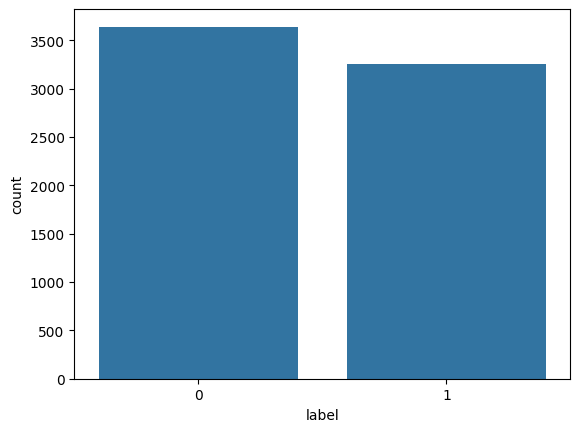

In [6]:
sns.countplot(data=df, x='label');

La variable ``sex`` presenta un desbalance importante. Para evitarlo se pueden usar técnicas durante en el pipeline del modelo final con ``fairlearn`` 

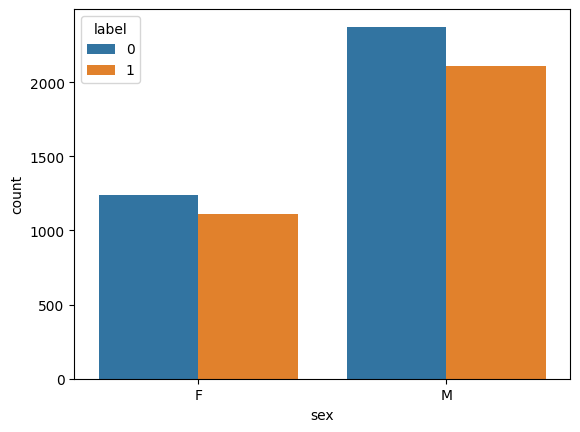

In [17]:
sns.countplot(data=df, x='sex', hue='label');

Vemos las edades, faltan datos entre 20 y 40. No se puede hacer mucho porque no hay datos que duplicar. Simplemente habrá que documentar la limitación.

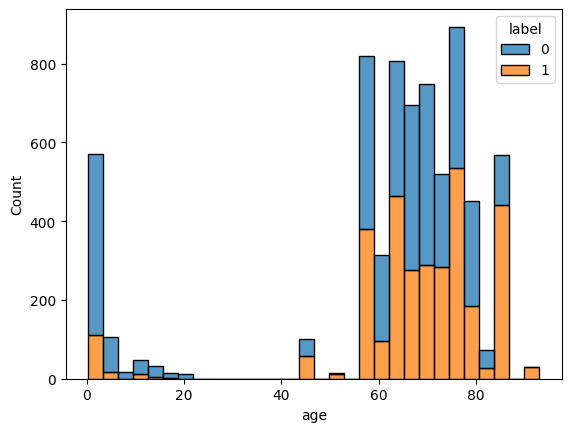

In [ ]:
sns.histplot(data=df, x='age', bins=30, hue='label', multiple='stack');

Ver los pacientes de bronchiolitis menores de 20.

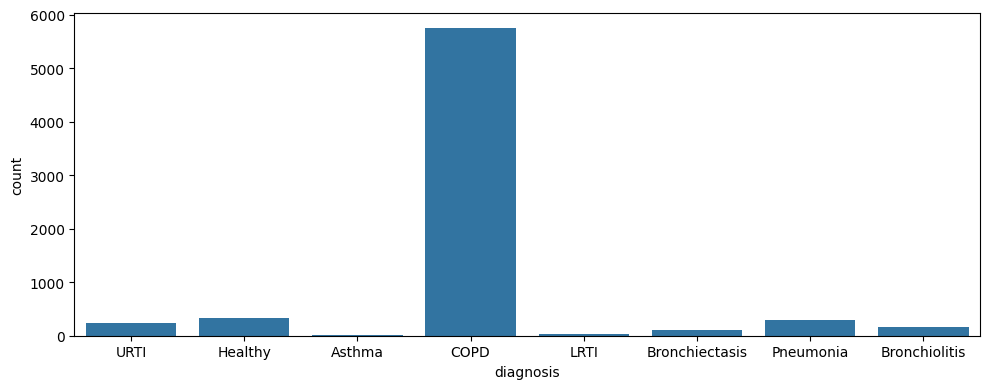

In [23]:
plt.figure(figsize=(10,4))
sns.countplot(data=df, x='diagnosis')
plt.tight_layout();

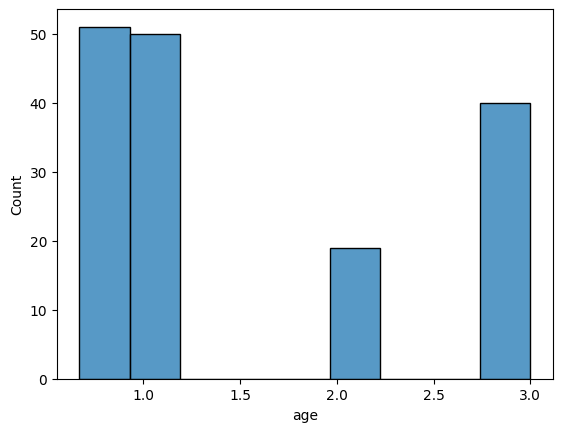

In [28]:
sns.histplot(data=df[df['diagnosis'] == 'Bronchiolitis'], x='age');

Son sólo 160 ciclos respiratorios, habría muchos duplicados. Además, son todos menos de 3 años y la idea era ver adolescentes.

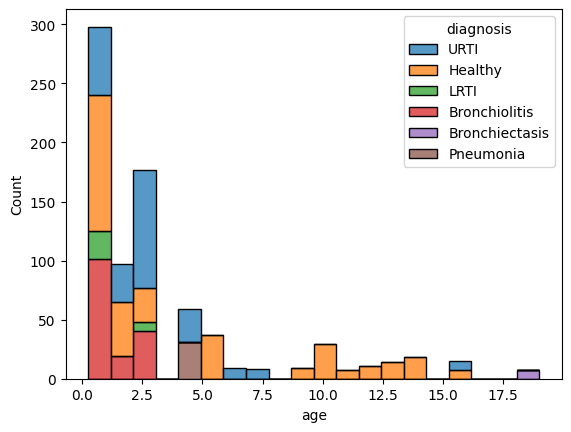

In [29]:
sns.histplot(data=df[df['age'] < 20], x='age', bins=20, hue='diagnosis', multiple='stack');

Los adolescentes son pacientes sanos

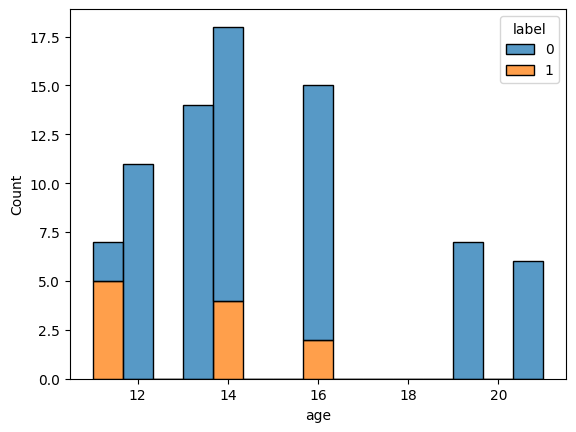

In [33]:
sns.histplot(data=df[(df['age'] < 25) & (df['age'] > 10)], x='age', hue='label', multiple='stack', bins=15);

## Separar en Conjuntos de Entrenamiento y Prueba fijos

**NO ESTAN BALANCEADOS. NO SE TRATÓ EL TEMA DE LAS DURACIONES NI NADA!!!!!!!!!!!!**

In [ ]:
dfs = [dataset_filtrado, dataset_completo]
folders = ['filtrado', 'completo']

for df, folder in zip(dfs, folders):
    train, test =  train_test_split(df[['cycle_wav_file', 'label']], test_size=TEST_SIZE, random_state=SEED, stratify=df['label'])
    os.makedirs(f'.dataset/{folder}', exist_ok=True)
    train.to_csv(f'.dataset/{folder}/train.csv', index=False)
    test.to_csv(f'.dataset/{folder}/test.csv', index=False)

**AGREGAR DATA AUGMENTATION CON PADDING** para dataset destinado a espectrogramas

Si no el modelo no va a aprender a buscar sobre el final de un espectrograma, podemos hacer tres paddings (al final, al comienzo y ambos) o centrar todos si crece mucho el dataset.

# Mel espectrogramas

In [ ]:
pipeline_proc = Pipeline([
    ('filter_resample', AudioFilterResampler()),
    ('melspec', MelSpectrogramTransformer()),
    ('pad', SpectrogramPadder()),
    ('flatten', FlattenTransformer()),
    ('scaler', StandardScaler())
])

In [ ]:
X_train_paths = ['./dataset/ciclos/' + f for f in train['cycle_wav_file']]
X_test_paths = ['./dataset/ciclos/' + f for f in test['cycle_wav_file']]
y_train = train['label'].values
y_test = test['label'].values

In [ ]:
X_train_proc = pipeline_proc.fit_transform(X_train_paths)
X_test_proc = pipeline_proc.transform(X_test_paths)

In [ ]:
X_train_proc_df = pd.DataFrame(X_train_proc)
X_test_proc_df = pd.DataFrame(X_test_proc)

X_train_proc_df['label'] = y_train
X_test_proc_df['label'] = y_test

In [ ]:
X_train_proc_df.to_csv('./dataset/ciclos/filtrado/train_melspectrogram.csv', index=False)
X_test_proc_df.to_csv('./dataset/ciclos/filtrado/test_melspectrogram.csv', index=False)

## Features

In [ ]:
pipeline_feature_extraction = Pipeline([
    ('filter_resample', AudioFilterResampler()),
    ('feature_extractor', FeatureExtractor()),
    ('scaler', StandardScaler())
])

In [ ]:
X_train_proc = pipeline_proc.fit_transform(X_train_paths)
X_test_proc = pipeline_proc.transform(X_test_paths)

In [ ]:
X_train_proc_df = pd.DataFrame(X_train_proc, columns=[
    'mfcc_' + str(i) for i in range(1, 14)] + [
] + [
    'zcr',
    'energy',
    'spectral_centroid',
    'spectral_rolloff',
    'ber',
    'spectral_flatness'
])

X_test_proc_df = pd.DataFrame(X_test_proc, columns=[
    'mfcc_' + str(i) for i in range(1, 14)] + [
] + [
    'zcr',
    'energy',
    'spectral_centroid',
    'spectral_rolloff',
    'ber',
    'spectral_flatness'
])

X_train_proc_df['label'] = y_train
X_test_proc_df['label'] = y_test

In [ ]:
X_train_proc_df.to_csv('./dataset/ciclos/filtrado/train_features.csv', index=False)
X_test_proc_df.to_csv('./dataset/ciclos/filtrado/test_features.csv', index=False)